# Import Libraries and implement logger

In [344]:
## IMPORT LIBRARIES
import logging
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from datetime import datetime
from dataclasses import dataclass
from sklearn. model_selection import train_test_split
from sklearn. preprocessing import MinMaxScaler

In [345]:
# CREATE LOGGER FOR JUPYTER NOTEBOOKS
def setup_logger():
    # Create logger instance
    logger = logging.getLogger(__name__)
    logger.setLevel(logging.INFO)

    # Clear existing, avoid duplicate logs
    if logger.hasHandlers():
        logger.handlers.clear()
    
    # Create FileHandler in overrite mode
    file_handler = logging.FileHandler('lognotebooks.log', mode ='w')

    # Set format
    formatter = logging.Formatter('%(asctime)s - %(levelno)s - %(lineno)d - %(module)s - %(message)s')
    file_handler.setFormatter(formatter)

    # Add FileHandler to logger
    logger.addHandler(file_handler)

    return logger

# Inspct the data read in after the data preperation

In [346]:
## Define function for inspection
logger = setup_logger()
def inspect_raw_data(df, output_path=None):
    '''
    Inspect a DataFrame and save info to a text file.
    Parameters:
    df : pandas DataFrame
    output_path : Path or str, optional
        Where to save the output file. If None and save_to_file is True,
        will use current directory
    '''

    # Set display options
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    
    # Prepare the information
    info_text = []
    info_text.append(f"Generated on: {datetime.now()}")
    info_text.append(f"Shape: {df.shape}")
    
    # Get info in string format
    buffer = StringIO()
    df.info(buf=buffer)
    info_text.append(f"\nDataFrame Info:")
    info_text.append(buffer.getvalue())

    # Add first 5 rows
    buffer_head = StringIO()
    df.head().to_string(buf=buffer_head)
    info_text.append(f"\nFirst 5 rows:")
    info_text.append(buffer_head.getvalue())

    # Add last 5 rows
    buffer_tail = StringIO()
    df.tail().to_string(buf=buffer_tail)
    info_text.append(f"\nLast 5 rows:")
    info_text.append(buffer_tail.getvalue())
    
    # Join all information
    full_report = '\n'.join(info_text)
    output_path = Path(output_path)
    output_path.write_text(full_report)
    logger.info(f"Report saved to: {output_path}")
    
    return full_report

In [347]:
# CALL FUNCTION FOR INSPECTION 
data_path = Path('..') / '..' / 'data' / 'processed' / 'DataPrep' 
for file in data_path.glob('*.csv'):
    logger.info(f'Available csv file: {file.name}')

# Read in data
df_eso = pd.read_csv(data_path / 'merged_eso_data.csv', delimiter=',', parse_dates=['ID']) #, parse_dates=['ID']
df_ger = pd.read_csv(data_path / 'merged_smard_data.csv', delimiter=',', parse_dates=['ID']) #, parse_dates=['ID']

eso = 'eso'; ger = 'ger'
inspect_raw_data(df_eso, output_path=Path(f'{data_path}/../Visualizer/{eso}_inspection.txt'))
inspect_raw_data(df_ger, output_path=Path(f'{data_path}/../Visualizer/{ger}_inspection.txt'))

"Generated on: 2024-11-20 12:26:34.183112\nShape: (129767, 66)\n\nDataFrame Info:\n<class 'pandas.core.frame.DataFrame'>\nRangeIndex: 129767 entries, 0 to 129766\nData columns (total 66 columns):\n #   Column                                                    Non-Null Count   Dtype         \n---  ------                                                    --------------   -----         \n 0   ID                                                        129767 non-null  datetime64[ns]\n 1   Stromfluss_Nettoexport [MWh]                              129767 non-null  float64       \n 2   Stromfluss_Niederlande (Export) [MWh]                     129767 non-null  float64       \n 3   Stromfluss_Niederlande (Import) [MWh]                     129767 non-null  float64       \n 4   Stromfluss_Schweiz (Export) [MWh]                         129767 non-null  float64       \n 5   Stromfluss_Schweiz (Import) [MWh]                         129767 non-null  float64       \n 6   Stromfluss_Dänemark (Export) [

# Compare features of the whole dataset
Check eso_inspection.txt and smard_inspection.txt in the 'processed' directory.

The table shows the features that are manually assignable at the first check.

                                               
| UK (eso)      | German (ger)                                                      |
|------------|------------------------------------------------------------------|
| Power Generation by Source:                                                   |
| GAS        | Erzeugung_Erdgas [MWh]                                           |
| COAL       | Erzeugung_Steinkohle [MWh] + Erzeugung_Braunkohle [MWh]          |
| NUCLEAR    | Erzeugung_Kernenergie [MWh]                                      |
| WIND       | Erzeugung_Wind Offshore [MWh] + Erzeugung_Wind Onshore [MWh]     |
| HYDRO      | Erzeugung_Wasserkraft [MWh]                                      |
| BIOMASS    | Erzeugung_Biomasse [MWh]                                         |
| SOLAR      | Erzeugung_Photovoltaik [MWh]                                     |
| STORAGE    | Erzeugung_Pumpspeicher [MWh]                                     |
| Demand/Load:                                                                  |
| ENGLAND_WALES_DEMAND  | Stromverbrauch_Gesamt (Netzlast) [MWh]                |
| PUMP_STORAGE_PUMPING  | Stromverbrauch_Pumpspeicher [MWh]                     |
| Cross-border flows (various interconnector flows):                            |          
| IFA_FLOW              | Stromfluss_Niederlande (Export/Import)                |
| BRITNED_FLOW          | Stromfluss_Frankreich (Export/Import)                 |
| MOYLE_FLOW            | Stromfluss_Polen (Export/Import)                      |
| etc.                  | etc.                                                  |
| System Balancing:                                                             |
| Energy Imbalance          |  Ausgleichsenergie_Volumen (+/-) [MWh]            |
| Frequency Control         |  Sekund_Abgerufene Menge (+/-) [MWh]              |
| Positive/Negative Reserve |   Minutenreserve_Abgerufene Menge (+/-) [MWh]     |


# Visualize comparable feature of the whole dataset

In [ ]:
# DEFINE VISUALIZER CLASS
@dataclass
class Visualizer:
    df_eso: pd.DataFrame
    df_ger: pd.DataFrame

    def __post_init__(self):
        self.eso_power_gen = {
            'FOSSIL': self.df_eso['GAS'] + self.df_eso['COAL'],
            'NUCLEAR': self.df_eso['NUCLEAR'],
            'RENEW': self.df_eso['WIND'] + self.df_eso['HYDRO'] + self.df_eso['BIOMASS'] + self.df_eso['SOLAR'],
            'PUMP_STORAGE': self.df_eso['STORAGE']
        }

        self.eso_demand = {
            'OVERALL': self.df_eso['ENGLAND_WALES_DEMAND'],
            'PUMP_STORAGE': self.df_eso['PUMP_STORAGE_PUMPING']
        }

        self.eso_balancing = {
            'Energy Imbalance': self.df_eso['Energy Imbalance (MWh)'],
            'Frequency Control': self.df_eso['Frequency Control Offers (MWh)'] - self.df_eso['Frequency Control Bids (MWh)'],
            'Positive Reserve': self.df_eso['Positive Reserve (MWh)'],
            'Negative Reserve': self.df_eso['Negative Reserve (MWh)']
        }

        self.ger_power_gen = {
            'FOSSIL': self.df_ger['Erzeugung_Erdgas [MWh]'] + self.df_ger['Erzeugung_Steinkohle [MWh]'] + self.df_ger['Erzeugung_Braunkohle [MWh]'],
            'NUCLEAR': self.df_ger['Erzeugung_Kernenergie [MWh]'],
            'RENEW': self.df_ger['Erzeugung_Wind Offshore [MWh]'] + self.df_ger['Erzeugung_Wind Onshore [MWh]'] +
                     self.df_ger['Erzeugung_Wasserkraft [MWh]'] + self.df_ger['Erzeugung_Biomasse [MWh]'] +
                     self.df_ger['Erzeugung_Photovoltaik [MWh]'],
            'PUMP_STORAGE': self.df_ger['Erzeugung_Pumpspeicher [MWh]']
        }

        self.ger_demand = {
            'OVERALL': self.df_ger['Stromverbrauch_Gesamt (Netzlast) [MWh]'],
            'PUMP_STORAGE': self.df_ger['Stromverbrauch_Pumpspeicher [MWh]']
        }

        self.ger_balancing = {
            'Energy Imbalance': self.df_ger['Ausgleichsenergie_Volumen (+) [MWh]'] - self.df_ger['Ausgleichsenergie_Volumen (-) [MWh]'],
            'Frequency Control': self.df_ger['Sekund_Abgerufene Menge (+) [MWh]'] - self.df_ger['Sekund_Abgerufene Menge (-) [MWh]'],
            'Positive Reserve': self.df_ger['Minutenreserve_Abgerufene Menge (+) [MWh]'],
            'Negative Reserve': self.df_ger['Minutenreserve_Abgerufene Menge (-) [MWh]']
        }

    def normalize(self, data):
        """Normalize data to the range [0, 1]."""
        return (data - data.min()) / (data.max() - data.min())

    def plot_data(self, n=100):
        """Generate the plots for power_gen, demand, and balancing."""
        time_axis_eso = self.df_eso['ID']
        time_axis_ger = self.df_ger['ID']

        fig, axes = plt.subplots(5, 2, figsize=(15, 20), sharex=False)
        fig.suptitle("Energy Data Visualization", fontsize=16)

        # Power generation
        for i, category in enumerate(['FOSSIL', 'NUCLEAR']):
            ax = axes[0, i]
            ax.plot(time_axis_eso[::n], self.normalize(self.eso_power_gen[category])[::n], label=f"ESO {category}", color='blue')
            ax.plot(time_axis_ger[::n], self.normalize(self.ger_power_gen[category])[::n], label=f"GER {category}", color='orange')
            ax.set_title(f"Power Generation: {category}")
            ax.legend()
            ax.grid()

        for i, category in enumerate(['RENEW', 'PUMP_STORAGE']):
            ax = axes[1, i]
            ax.plot(time_axis_eso[::n], self.normalize(self.eso_power_gen[category])[::n], label=f"ESO {category}", color='blue')
            ax.plot(time_axis_ger[::n], self.normalize(self.ger_power_gen[category])[::n], label=f"GER {category}", color='orange')
            ax.set_title(f"Power Generation: {category}")
            ax.legend()
            ax.grid()

        # Demand
        for i, category in enumerate(self.eso_demand.keys()):
            ax = axes[2, i]
            ax.plot(time_axis_eso[::n], self.normalize(self.eso_demand[category])[::n], label=f"ESO {category}", color='blue')
            ax.plot(time_axis_ger[::n], self.normalize(self.ger_demand[category])[::n], label=f"GER {category}", color='orange')
            ax.set_title(f"Demand: {category}")
            ax.legend()
            ax.grid()

        # Balancing - Energy Imbalance and Frequency Control
        for i, category in enumerate(['Energy Imbalance', 'Frequency Control']):
            ax = axes[3, i]
            ax.plot(time_axis_eso[::n], self.normalize(self.eso_balancing[category])[::n], label=f"ESO {category}", color='blue')
            ax.plot(time_axis_ger[::n], self.normalize(self.ger_balancing[category])[::n], label=f"GER {category}", color='orange')
            ax.set_title(f"Balancing: {category}")
            ax.legend()
            ax.grid()

        # Balancing - Positive and Negative Reserve
        for i, category in enumerate(['Positive Reserve', 'Negative Reserve']):
            ax = axes[4, i]
            ax.plot(time_axis_eso[::n], self.normalize(self.eso_balancing[category])[::n], label=f"ESO {category}", color='blue')
            ax.plot(time_axis_ger[::n], self.normalize(self.ger_balancing[category])[::n], label=f"GER {category}", color='orange')
            ax.set_title(f"Balancing: {category}")
            ax.legend()
            ax.grid()

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    def plot_correlation_heatmap(self, features_eso, features_ger, figsize=(12, 10)):
        """
        Parameters:
        features_to_analyze (list): List of feature names to include in the correlation heatmap
        figsize (tuple): Size of the figure (width, height)
        """
        plt.figure(figsize=figsize)
        correlation_matrix = self.df_eso[features_eso].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Feature Correlation Heatmap - ESO')
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=figsize)
        correlation_matrix = self.df_ger[features_ger].corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
        plt.title('Feature Correlation Heatmap - GER')
        plt.tight_layout()
        plt.show()



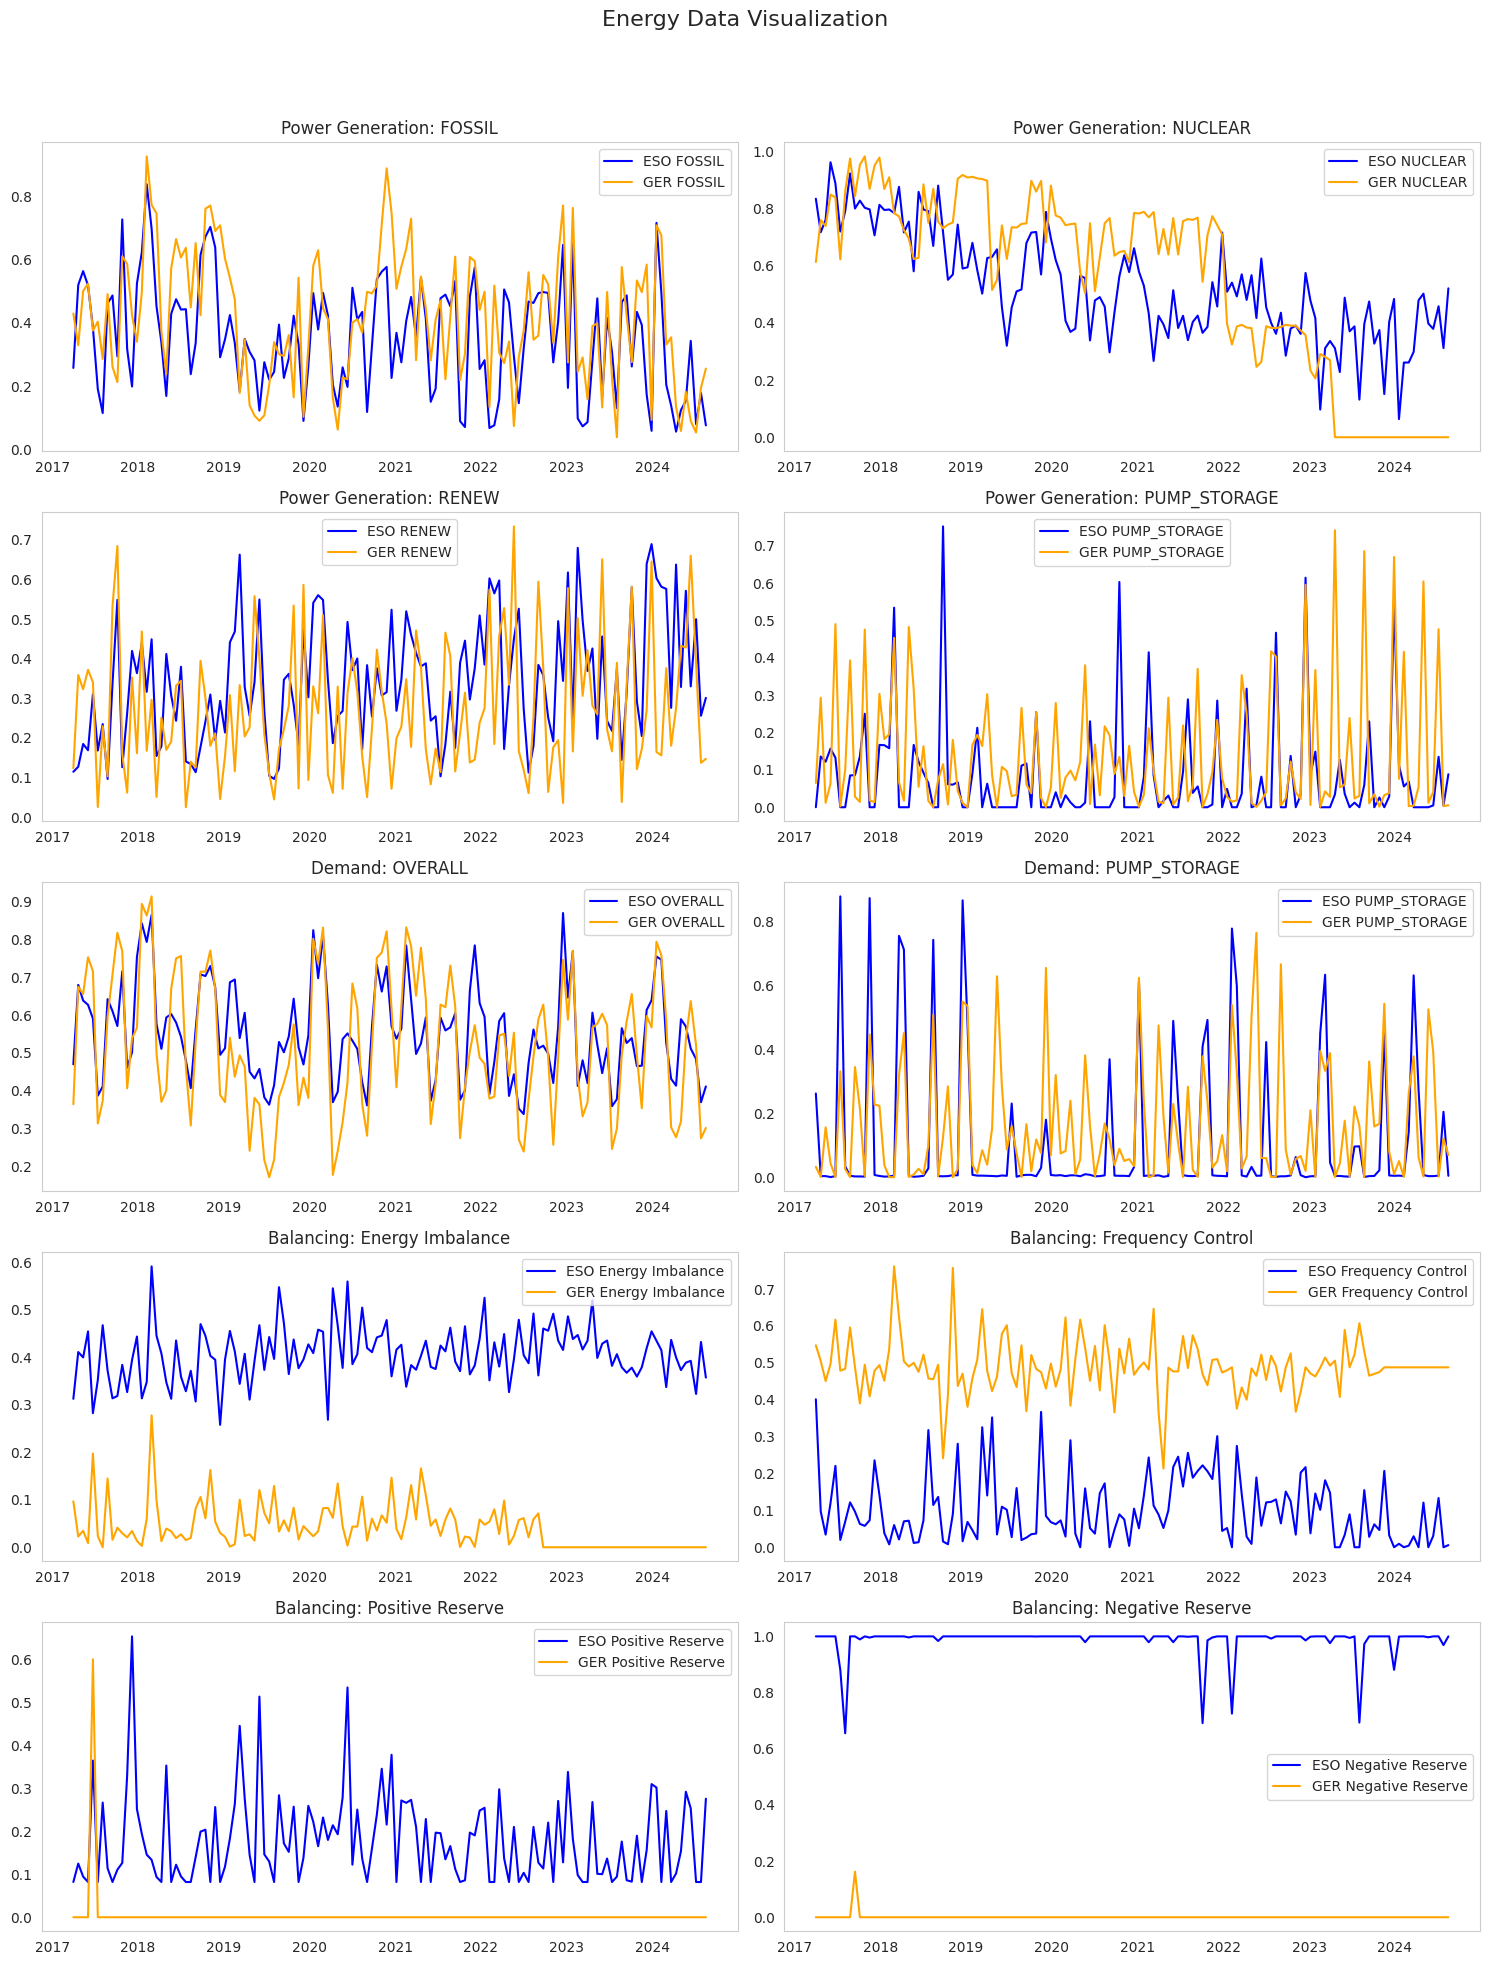

In [349]:
# VISUALIZE COMPARALE FEATURE OVER TIME
visualizer = Visualizer(df_eso, df_ger)
visualizer.plot_data(n=1000)

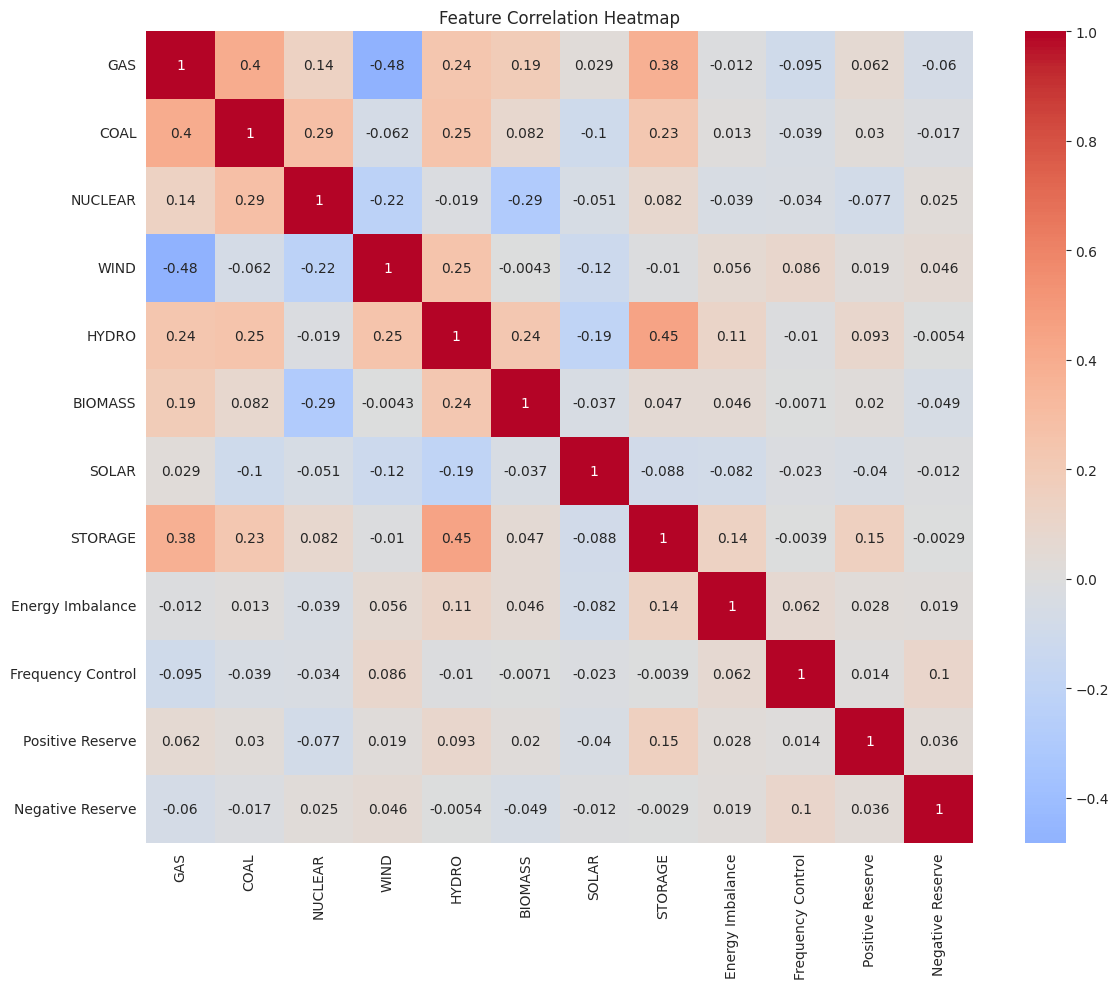

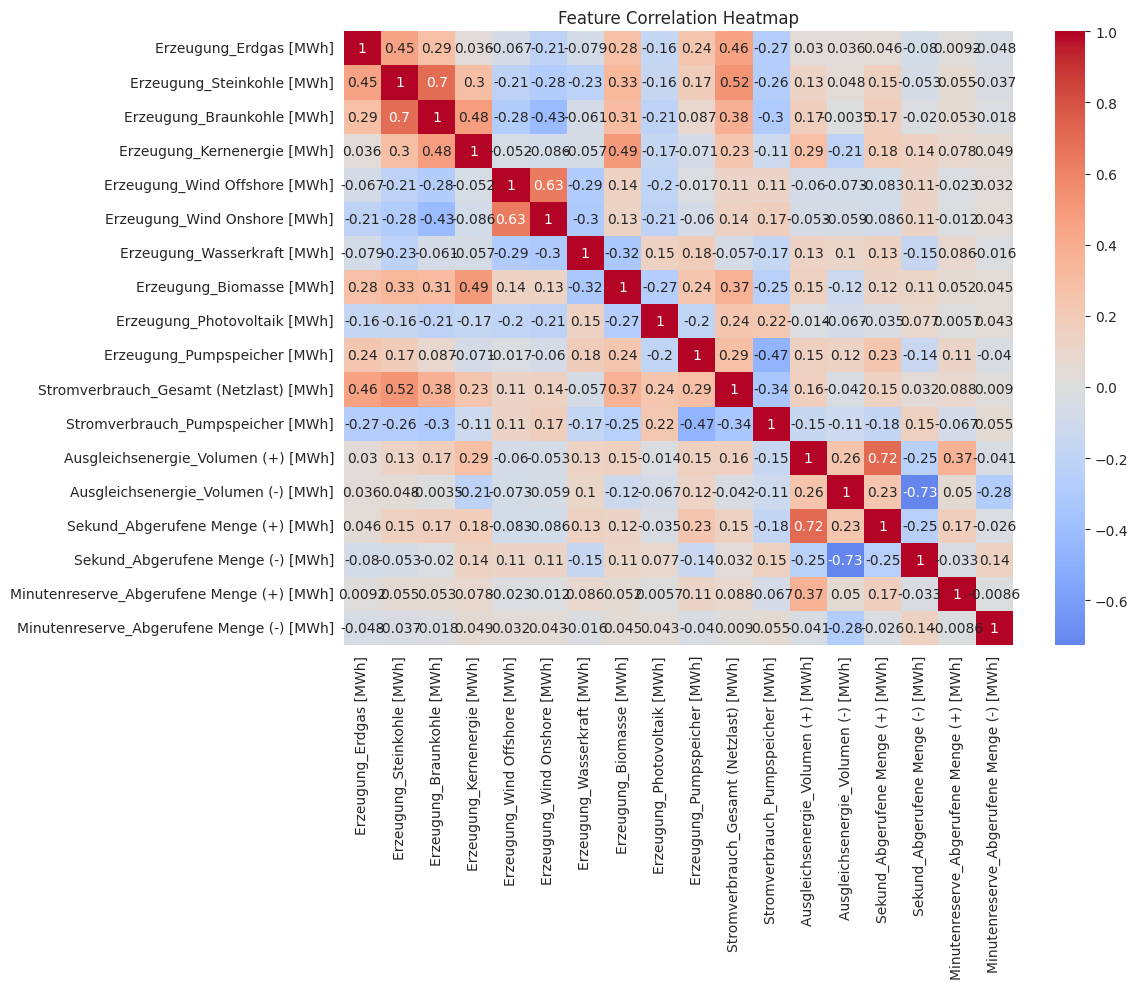

In [356]:
# VISUALIZE CORRELATION HEATMAP of COMPARABLE FEATURES
features_eso = ['GAS', 'COAL', 'NUCLEAR', 'WIND', 'HYDRO', 'BIOMASS', 'SOLAR', 'STORAGE',
               'Energy Imbalance', 'Frequency Control', 'Positive Reserve', 'Negative Reserve']

# Plot GER features
features_ger = ['Erzeugung_Erdgas [MWh]', 'Erzeugung_Steinkohle [MWh]', 'Erzeugung_Braunkohle [MWh]',
               'Erzeugung_Kernenergie [MWh]', 'Erzeugung_Wind Offshore [MWh]', 'Erzeugung_Wind Onshore [MWh]',
               'Erzeugung_Wasserkraft [MWh]', 'Erzeugung_Biomasse [MWh]', 'Erzeugung_Photovoltaik [MWh]',
               'Erzeugung_Pumpspeicher [MWh]',
               'Stromverbrauch_Gesamt (Netzlast) [MWh]', 'Stromverbrauch_Pumpspeicher [MWh]',
               'Ausgleichsenergie_Volumen (+) [MWh]', 'Ausgleichsenergie_Volumen (-) [MWh]',
               'Sekund_Abgerufene Menge (+) [MWh]', 'Sekund_Abgerufene Menge (-) [MWh]',
               'Minutenreserve_Abgerufene Menge (+) [MWh]', 'Minutenreserve_Abgerufene Menge (-) [MWh]']

visualizer = Visualizer(df_eso, df_ger)
visualizer.plot_correlation_heatmap(features_eso, features_ger)


# SPLIT THE DATA

![Train Test Split for modeling process](../../data/figures/modeling_process.png)

In [351]:
## SPLITTING DATA
# ESO
eso_combine_cols = df_eso['GAS'] + df_eso['COAL']
df_eso['FOSSIL'] = eso_combine_cols 

eso_target = df_eso['FOSSIL']

X_eso_dd = df_eso.loc[:, ~df_eso.columns.isin(eso_target + eso_combine_cols)]
y_eso_dd = eso_target

X_train_eso, X_test_eso, y_train_eso, y_test_eso = train_test_split(X_eso_dd, y_eso_dd, test_size=0.25, random_state=42)

# GER
ger_combine_cols = df_ger['Erzeugung_Erdgas [MWh]'] + df_ger['Erzeugung_Steinkohle [MWh]'] + df_ger['Erzeugung_Braunkohle [MWh]']
df_ger['FOSSIL'] = ger_combine_cols

ger_target = df_ger['FOSSIL']

X_ger_dd = df_ger.loc[:, ~df_ger.columns.isin(ger_target + ger_combine_cols)]
y_ger_dd = ger_target

X_train_ger, X_test_ger, y_train_ger, y_test_ger = train_test_split(X_ger_dd, y_ger_dd, test_size=0.25, random_state=42)

# NORMALIZE THE TRAIN DATA

In [352]:
## NORMALIZE
def normalize(X_train, X_test):

    # Sort both datasets by ID
    X_train = X_train.sort_values('ID')
    X_test = X_test.sort_values('ID')

    # Initialize scaler
    scaler = MinMaxScaler()
    
    # Get all columns except 'ID'
    cols_to_scale = [col for col in X_train.columns if col != 'ID']
    
    # Fit and transform all columns except ID
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    
    # Fit on training data and transform both
    scaler.fit(X_train[cols_to_scale])
    X_train_scaled[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
    X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
    
    return X_train_scaled, X_test_scaled

X_train_eso_scaled, X_test_eso_scaled = normalize(X_train_eso, X_test_eso)
X_train_ger_scaled, X_test_ger_scaled = normalize(X_train_ger, X_test_ger)

eso_scaled = 'eso_sc'; ger_scaled = 'ger_sc'
inspect_raw_data(X_train_eso_scaled, output_path=Path(f'{data_path}/../Visualizer/{eso_scaled}_inspection.txt'))
inspect_raw_data(X_train_ger_scaled, output_path=Path(f'{data_path}/../Visualizer/{ger_scaled}_inspection.txt'))

"Generated on: 2024-11-20 12:26:43.270736\nShape: (97325, 67)\n\nDataFrame Info:\n<class 'pandas.core.frame.DataFrame'>\nIndex: 97325 entries, 1 to 129766\nData columns (total 67 columns):\n #   Column                                                    Non-Null Count  Dtype         \n---  ------                                                    --------------  -----         \n 0   ID                                                        97325 non-null  datetime64[ns]\n 1   Stromfluss_Nettoexport [MWh]                              97325 non-null  float64       \n 2   Stromfluss_Niederlande (Export) [MWh]                     97325 non-null  float64       \n 3   Stromfluss_Niederlande (Import) [MWh]                     97325 non-null  float64       \n 4   Stromfluss_Schweiz (Export) [MWh]                         97325 non-null  float64       \n 5   Stromfluss_Schweiz (Import) [MWh]                         97325 non-null  float64       \n 6   Stromfluss_Dänemark (Export) [MWh]           

# MAKE CORRELATION MATRIX 

In [353]:

important_features = [
        'GAS_perc', 'NUCLEAR_perc', 'WIND_perc', 'SOLAR_perc',
        'CARBON_INTENSITY', 'RENEWABLE_perc', 'FOSSIL_perc',
        'Outturn Inertia', 'Market Provided Inertia'
    ]
    plot_correlation_heatmap(df_vis, important_features)


IndentationError: unexpected indent (811687590.py, line 6)